# Pion Stop Training (Unified Config Pipeline)

Train the pion-stop regressor from aligned upstream prediction shards using the unified config-driven training pipeline.

## 1) Environment Setup

In [1]:
from pathlib import Path

from pioneerml.evaluation.plots.loss import LossCurvesPlot
from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils
from pioneerml.pipeline.pipelines.training import training_pipeline

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)

Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).


## 2) Select and Align Input Files

In [2]:
def _pick_pred(pred_dir: Path, main_path: Path) -> Path | None:
    candidates = [
        pred_dir / f"{main_path.stem}_preds.parquet",
        pred_dir / f"{main_path.stem}_preds_latest.parquet",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def resolve_aligned_inputs(*, project_root: str, max_files: int | None = 1) -> dict:
    data_dir = Path(project_root) / "data"
    main_paths = sorted(data_dir.glob("ml_output_*.parquet"))
    if max_files is not None:
        main_paths = main_paths[: int(max_files)]
    if not main_paths:
        raise RuntimeError(f"No main parquet files found in {data_dir}.")

    dirs = {
        "group_probs": data_dir / "group_classifier",
        "group_splitter": data_dir / "group_splitter",
        "endpoint": data_dir / "endpoint_regressor",
        "event_splitter": data_dir / "event_splitter",
    }

    aligned: list[tuple[Path, Path, Path, Path, Path]] = []
    for main in main_paths:
        gp = _pick_pred(dirs["group_probs"], main)
        gs = _pick_pred(dirs["group_splitter"], main)
        ep = _pick_pred(dirs["endpoint"], main)
        es = _pick_pred(dirs["event_splitter"], main)
        if not (gp and gs and ep and es):
            missing = []
            if gp is None:
                missing.append("group_classifier")
            if gs is None:
                missing.append("group_splitter")
            if ep is None:
                missing.append("endpoint_regressor")
            if es is None:
                missing.append("event_splitter")
            raise RuntimeError(f"Missing aligned predictions for {main.name}: {', '.join(missing)}")
        aligned.append((main, gp, gs, ep, es))

    return {
        "main_sources": [str(m.resolve()) for (m, _, _, _, _) in aligned],
        "optional_sources_by_name": {
            "group_probs": [str(gp.resolve()) for (_, gp, _, _, _) in aligned],
            "group_splitter": [str(gs.resolve()) for (_, _, gs, _, _) in aligned],
            "endpoint": [str(ep.resolve()) for (_, _, _, ep, _) in aligned],
            "event_splitter": [str(es.resolve()) for (_, _, _, _, es) in aligned],
        },
        "source_type": "file",
    }


input_sources_spec = resolve_aligned_inputs(project_root=PROJECT_ROOT, max_files=1)
print(f"Using {len(input_sources_spec['main_sources'])} aligned shard(s).")
for src in input_sources_spec["main_sources"]:
    print(" -", src)

Using 1 aligned shard(s).
 - /workspace/data/ml_output_000.parquet


## 3) Reusable Config Helpers

In [3]:
from pioneerml.plugin.runtime import ensure_plugins_loaded
ensure_plugins_loaded()

from pioneerml_base_plugin.pion_stop.pipeline import load_config
from pioneerml_base_plugin.utils.config_loader import with_export_output, with_loader_sources


## 4) Build Step Config Blocks

In [4]:
pipeline_config = load_config()["training"]
pipeline_config = with_loader_sources(
    pipeline_config,
    main_sources=input_sources_spec["main_sources"],
    optional_sources_by_name=input_sources_spec["optional_sources_by_name"],
)
pipeline_config = with_export_output(
    pipeline_config,
    export_dir=str(Path(PROJECT_ROOT) / "trained_models" / "pion_stop_regression"),
    filename_prefix="pion_stop",
)


## 5) Assemble `pipeline_config` and Run

In [5]:
run = training_pipeline.with_options(enable_cache=False)(
    pipeline_config=pipeline_config,
)


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.


[I 2026-03-26 01:37:46,898] A new study created in RDB with name: pion_stop_hpo


[tune_model] GPU available: True (cuda), used: True
[tune_model] TPU available: False, using: 0 TPU cores
[tune_model] You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set torch.set_float32_matmul_precision('medium' | 'high') which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
[tune_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PionStopRegressor   │  2.0 M │ train │     0 │
│ 1 │ loss_fn │ QuantilePinballLoss │      0 │ train │     0 │
└───┴─────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 2.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.0 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 62                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Step tune_model has finished in 1m7s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PionStopRegressor   │  667 K │ train │     0 │
│ 1 │ loss_fn │ QuantilePinballLoss │      0 │ train │     0 │
└───┴─────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 667 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 667 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 62                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] No materializer is registered for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'>, so the default Pickle materializer was used. Pickle is not production ready and should only be used for prototyping as the artifacts cannot be loaded when running with a different Python version. Please consider implementing a custom materializer for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'> according to the instructions at https://docs.zenml.io/concepts/artifacts/materializers
Step train_model has finished in 1m22s.
Step evaluate_model has started.
Step evaluate_model has finished in 1.445s.
Step export_model has started.
Step export_model has finished in 1.393s.
Pipeline run has finished in 2m36s.


## 6) Load Step Outputs and Inspect Results

hpo_params: {'study_name': 'pion_stop_hpo', 'storage': 'sqlite:////workspace/.optuna/pion_stop_hpo.db', 'best_params': {'batch_size_exp': 5, 'lr': 0.00048725749205699487, 'weight_decay': 0.0006472344123799732, 'hidden': 128, 'dropout': 0.11052482362251244, 'batch_size': 32}}
metrics: {'loss': 0.48771191053810853, 'mae': 1.4115537212369191, 'train_loss_history': [1.1247600265873205, 0.6723432058828256, 0.6090717190832755, 0.5872503136942672, 0.5642528539701879, 0.5561585193851308, 0.5412153389733747, 0.5419398515849527, 0.528019660232683, 0.5240007170032432, 0.5205516904275366, 0.5201162997848255, 0.520582518359224, 0.5199256222292671, 0.5182316905065953], 'train_loss_history_total_points': 15, 'val_loss_history': [2.524353861808777, 0.5922644332963594, 0.5389964501468503, 0.4880950183284526, 0.4955468427161781, 0.45795124982084545, 0.45225806047721784, 0.44315515428173297, 0.43778399332445495, 0.4393203124708059, 0.4344200139143029, 0.4321541120203174, 0.4254455754951555, 0.42439709877

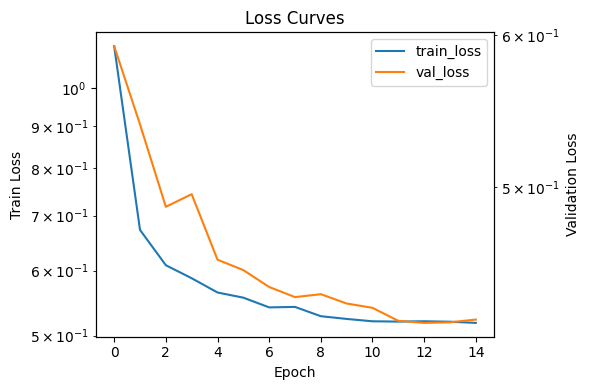

In [6]:
hpo_output = load_step_output(run, "tune_model")
train_output = load_step_output(run, "train_model")
evaluate_output = load_step_output(run, "evaluate_model")
export_output = load_step_output(run, "export_model")

hpo_params = hpo_output.get("hpo_params") if isinstance(hpo_output, dict) else hpo_output
trained_module = train_output.get("module") if isinstance(train_output, dict) else train_output
metrics = evaluate_output.get("metrics") if isinstance(evaluate_output, dict) else evaluate_output

print("hpo_params:", hpo_params)
print("metrics:", metrics)
print("export:", export_output)

if trained_module is None:
    raise RuntimeError("No trained module loaded from pipeline run.")

LossCurvesPlot().render(trained_module, show=True)